#### Assignment #1 - Part 1 - Average Salary of Teachers in Chicago
-   Data cleansing 
-   Select the right rows for teachers 
-   Delete na values or impute 
-   Winsorze for outliers and compute summary stats

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import mstats
import matplotlib.pyplot as plt

In [9]:
sal = pd.read_excel(r"data\\EmployeePositionRoster_06302023.xlsx")
# print('Date shape:',sal.shape)
# print('Data Columns:',sal.columns)

In [10]:
# Check missing Annual Salary values in the full dataset
annual_salary_nulls = sal['Annual Salary'].isna().sum()
annual_salary_null_pct = (annual_salary_nulls / sal.shape[0]) * 100
print('Annual Salary null count:', annual_salary_nulls)
print('Annual Salary null % of total rows:', round(annual_salary_null_pct, 2), '%')

# delete rows with null Annual Salary values
sal_no_na = sal[~sal['Annual Salary'].isna()]
print('Date shape after removing nulls:',sal_no_na.shape)


Annual Salary null count: 4126
Annual Salary null % of total rows: 9.15 %
Date shape after removing nulls: (40944, 11)


In [11]:
# Check for non-numeric text in Annual Salary
annual_salary_series = sal_no_na['Annual Salary']

annual_salary_is_numeric = pd.to_numeric(annual_salary_series, errors='coerce')
non_numeric_mask = annual_salary_series.notna() & annual_salary_is_numeric.isna()
print('Annual Salary dtype:', annual_salary_series.dtype)
print('Non-numeric Annual Salary count:', non_numeric_mask.sum())
print('Non-numeric Annual Salary % of total rows:', round((non_numeric_mask.sum() / sal_no_na.shape[0]) * 100, 2), '%')
if non_numeric_mask.any():
    print('Sample non-numeric values:', annual_salary_series[non_numeric_mask].head(10).tolist())

Annual Salary dtype: float64
Non-numeric Annual Salary count: 0
Non-numeric Annual Salary % of total rows: 0.0 %


<Axes: >

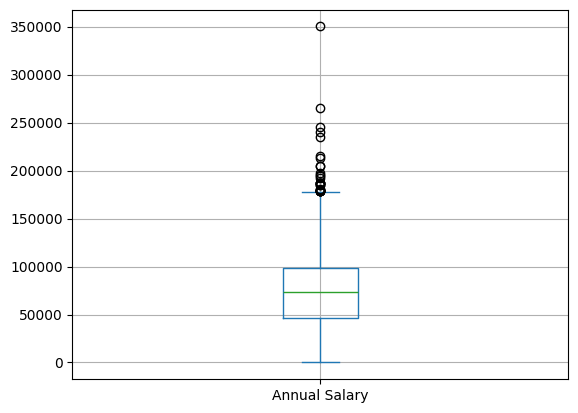

In [12]:
# box plot salary distribution
sal_no_na['Annual Salary'].plot(kind='box', grid=True)

Annual Salary == 0 count: 4
Annual Salary == 0 % of total rows: 0.01 %


<Axes: >

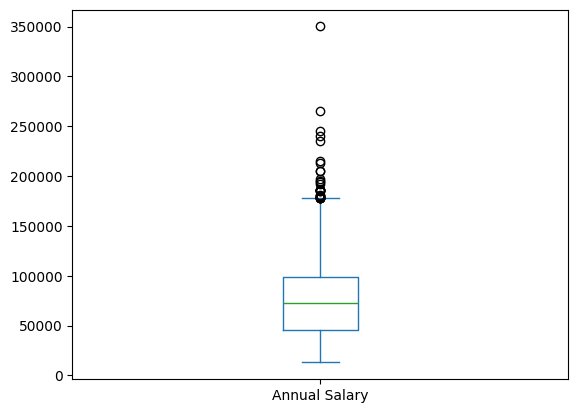

In [13]:


# check how many rows with 0 Annual salary - count and % of total
zero_salary_count = (sal_no_na['Annual Salary'] == 0).sum()
zero_salary_pct = (zero_salary_count / sal_no_na.shape[0]) * 100
print('Annual Salary == 0 count:', zero_salary_count)
print('Annual Salary == 0 % of total rows:', round(zero_salary_pct, 2), '%')

# delete these 4 rows with 0 annual salary
sal_no_na = sal_no_na[sal_no_na['Annual Salary'] > 0]
sal_no_na['Annual Salary'].plot(kind='box')

<Axes: >

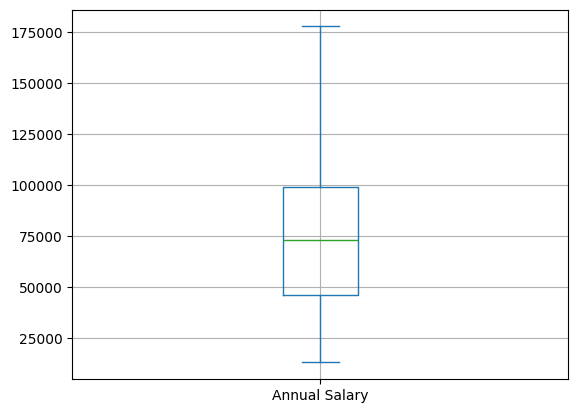

In [48]:
# Winsorize Annual Salary at .1% or 0.001 
sal_wins = sal_no_na.copy()

winsorized_values = mstats.winsorize(sal_wins['Annual Salary'], limits=[0.00, 0.001])
sal_wins['Annual Salary'] = winsorized_values
sal_wins['Annual Salary'].plot(kind='box', grid=True)

In [58]:
sal_no_na['Annual Salary'].describe()[['min', '25%', '50%', '75%', 'max']]

min     12993.0
25%     45992.0
50%     72964.0
75%     98922.0
max    350200.0
Name: Annual Salary, dtype: float64

In [59]:
hist_df = sal_wins.copy()
hist_df = sal_no_na.copy()

In [60]:
# Check skewness of Annual Salary distribution
skew_value = hist_df['Annual Salary'].skew()
if skew_value > 0:
    skew_label = 'right-skewed'
elif skew_value < 0:
    skew_label = 'left-skewed'
else:
    skew_label = 'approximately symmetric'
print('Skewness:', round(skew_value, 4))
print('Shape:', skew_label)

Skewness: 0.2169
Shape: right-skewed


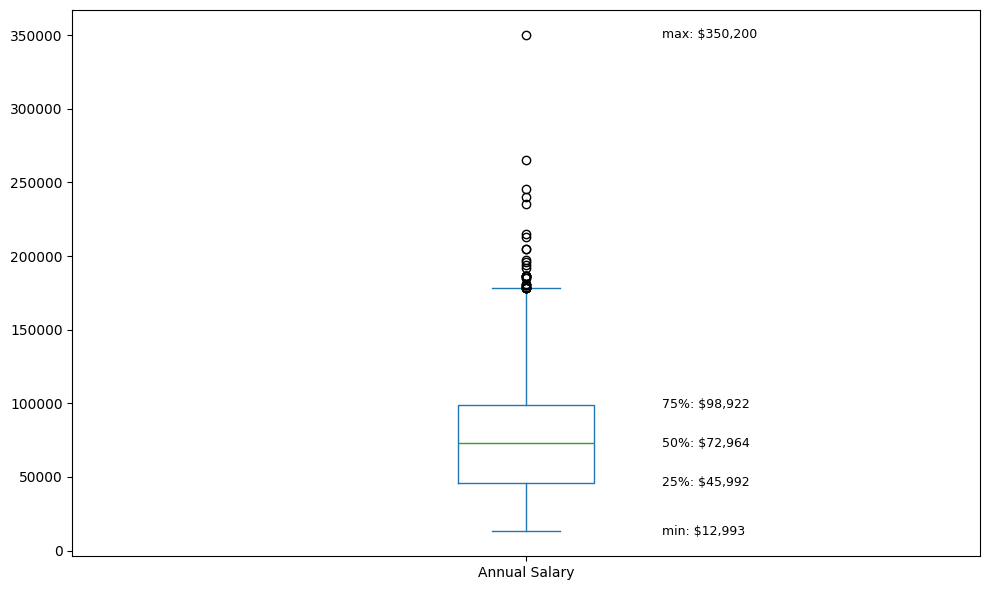

Five-Number Summary for Teacher Salaries (Winsorized):
min     12993.0
25%     45992.0
50%     72964.0
75%     98922.0
max    350200.0
Name: Annual Salary, dtype: float64


In [61]:
# get summary now and final box plot with labels
fig, ax = plt.subplots(figsize=(10, 6))
hist_df['Annual Salary'].plot(kind='box', ax=ax)

# Get five-number summary
q_values = hist_df['Annual Salary'].describe()[['min', '25%', '50%', '75%', 'max']]

# Add text annotations for each level, y value will match as that is what we are plotting
for i, (label, value) in enumerate(q_values.items()):
    ax.text(1.15, value, f'{label}: ${value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Five-Number Summary for Teacher Salaries (Winsorized):')
print(q_values)

In [62]:
df_hist=sal_no_na
# df_hist=sal_wins

--- Ranked 'Nice' Bin Widths ---
   Power (p)  Bin Width  Number of Bins  Cost (C)
1          4    12500.0              27 -0.038905
0          4    10000.0              34 -0.038102
2          4    20000.0              17 -0.035945
3          4    25000.0              14 -0.033964

Best 'Nice' Choice: Width = $12,500 (Bins: 27.0)


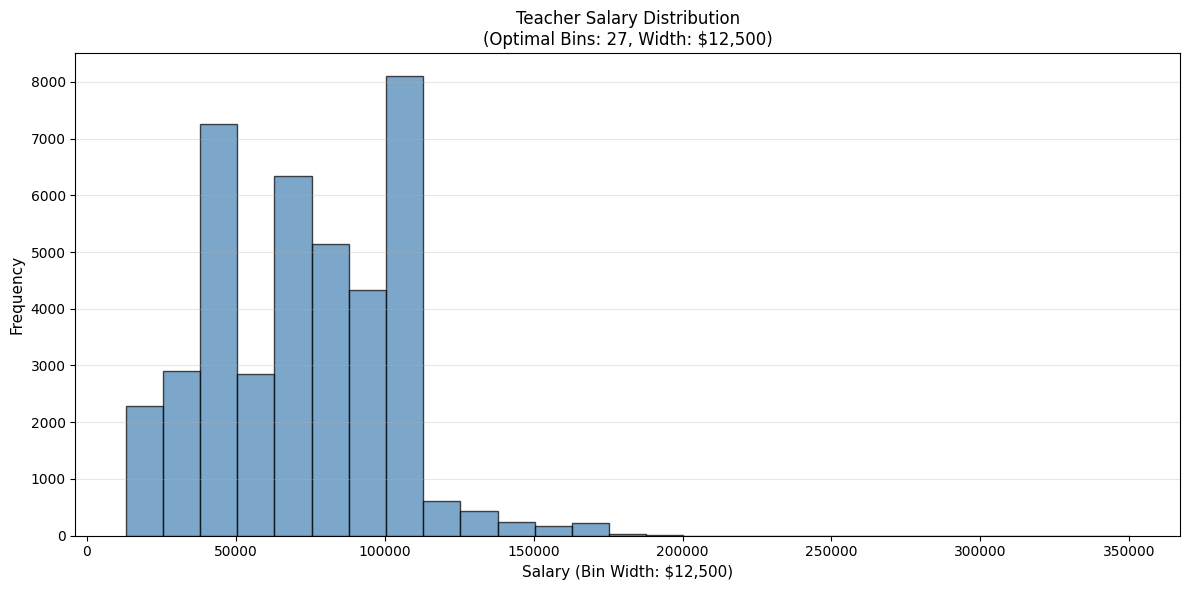

Histogram plotted with optimal bin width: $12,500
Number of bins: 27


In [63]:


salaries = df_hist['Annual Salary']
data_min = np.min(salaries)
data_max = np.max(salaries)
data_range = data_max - data_min

# 2. Define the "Nice Number" Candidates
base_candidates = [1, 1.25, 2, 2.5, 5]
powers_to_try = [2,3, 4] # Based on "Common Sense" for salaries (1k to 150k range)

nice_widths = []
for p in powers_to_try:
    for base in base_candidates:
        nice_widths.append(base * (10**p))

# 3. Evaluate Each "Nice" Width
results = []

for width in nice_widths:
    # Calculate number of bins for this width
    n_bins = int(np.ceil(data_range / width))
    
    # CONSTRAINT: Only consider if bins are between 10 and 50
    if 10 <= n_bins <= 50:
        
        # Shimazaki Cost Calculation
        edges = np.arange(data_min, data_max + width, width) # Create edges
        k, _ = np.histogram(salaries, bins=edges) # Count freq
        k_mean = np.mean(k)
        v = np.var(k)
        
        # The Cost Function
        C = (2 * k_mean - v) / (width ** 2)
        
        results.append({
            "Power (p)": np.log10(width/base_candidates[0] if width in base_candidates else width).astype(int), # approx p
            "Bin Width": width,
            "Number of Bins": n_bins,
            "Cost (C)": C
        })

# 4. Display Results
df_results = pd.DataFrame(results)

if not df_results.empty:
    df_sorted = df_results.sort_values(by="Cost (C)")
    print("--- Ranked 'Nice' Bin Widths ---")
    print(df_sorted)
    
    best_choice = df_sorted.iloc[0]
    print(f"\nBest 'Nice' Choice: Width = ${best_choice['Bin Width']:,.0f} (Bins: {best_choice['Number of Bins']})")
else:
    print("No 'Nice' widths resulted in a bin count between 10 and 50.")

# Plot histogram based on optimal bin width
fig, ax = plt.subplots(figsize=(12, 6))

# Extract best bin width and number of bins from previous analysis
optimal_width = best_choice['Bin Width']
optimal_bins = int(best_choice['Number of Bins'])

# Plot histogram with optimal bins
ax.hist(df_hist['Annual Salary'], bins=optimal_bins, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel(f'Salary (Bin Width: ${optimal_width:,.0f})', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Teacher Salary Distribution\n(Optimal Bins: {optimal_bins}, Width: ${optimal_width:,.0f})', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Histogram plotted with optimal bin width: ${optimal_width:,.0f}')
print(f'Number of bins: {optimal_bins}')

In [35]:


def univariate (y):
   '''Compute four descriptive statistics from first principles.

   Argument:
   ---------
   y : a Pandas Series of numeric values
   
   Output:
   -------
   y_nvalid : number of non-NaN values
   y_min : the minimum value
   y_max : the maximum value
   y_mean : the arithmetic mean
   '''

   # Initialize
   y_nvalid = 0
   y_min = None
   y_max = None
   y_mean = None

   # Loop through all the elements
   for u in y:
      if (not np.isnan(u)):
         y_nvalid = y_nvalid + 1

         if (y_min is not None):
            if (u < y_min):
               y_min = u
         else:
            y_min = u

         if (y_max is not None):
            if (u > y_max):
               y_max = u
         else:
            y_max = u

         if (y_mean is not None):
            y_mean = y_mean + u
         else:
            y_mean = u

   # Finalize
   if (y_nvalid > 0):
      y_mean = y_mean / y_nvalid

   return (y_nvalid, y_min, y_max, y_mean)


def shimazaki_criterion (y, d_list):
   '''Compute the criterion based on the Shimazaki H. and Shinomoto S. (2007) paper.

   Argument:
   ---------
   y : a Pandas Series of numeric values
   d_list : a list of candidates of bin-widths
   
   Output:
   -------
   number_bins : a list of number of bins (length is same as d_list)
   matrix_boundary : a list of bin boundaries, each element is a list
   criterion_list : a list of criterion values
   '''

   number_bins = []
   matrix_boundary = []
   criterion_list = []

   y_nvalid, y_min, y_max, y_mean = univariate (y)

   if (y_nvalid <= 0):
      raise ValueError('There are no non-missing values in the data vector.')
   else:

      # Loop through the bin width candidates
      for delta in d_list:
         y_middle = delta * np.round(y_mean / delta)
         n_bin_left = np.ceil((y_middle - y_min) / delta)
         n_bin_right = np.ceil((y_max - y_middle) / delta)
         y_low = y_middle - n_bin_left * delta

         # Assign observations to bins starting from 0
         list_boundary = []
         n_bin = n_bin_left + n_bin_right
         bin_index = 0
         bin_boundary = y_low
         for i in np.arange(n_bin):
            bin_boundary = bin_boundary + delta
            bin_index = np.where(y > bin_boundary, i+1, bin_index)
            list_boundary.append(bin_boundary)

         # Count the number of observations in each bins
         uvalue, ucount = np.unique(bin_index, return_counts = True)

         # Calculate the average frequency
         mean_ucount = np.mean(ucount)
         ssd_ucount = np.mean(np.power((ucount - mean_ucount), 2))
         criterion = (2.0 * mean_ucount - ssd_ucount) / delta / delta

         number_bins.append(n_bin)
         matrix_boundary.append(list_boundary)
         criterion_list.append(criterion)
        
   return(number_bins, matrix_boundary, criterion_list)


In [44]:

d_list = []
d0_list = [1.0, 1.25, 2.0, 2.5, 5.0]

for p in [3, 4]:
   d_list.extend([u * np.power(10.0, p) for u in d0_list])

number_bins, matrix_boundary, criterion_list = shimazaki_criterion(sal_no_na['Annual Salary'], d_list)

result_df = pd.DataFrame(columns = ['Bin-Width','N Bin','Criterion'])
result_df['Bin-Width'] = d_list
result_df['N Bin'] = number_bins
result_df['Criterion'] = criterion_list
# pandas Series
mask = (result_df['N Bin'] >= 10) & (result_df['N Bin'] <= 50)
final_df = result_df[mask]



In [36]:
d_list

[np.float64(1000.0),
 np.float64(1250.0),
 np.float64(2000.0),
 np.float64(2500.0),
 np.float64(5000.0),
 np.float64(10000.0),
 np.float64(12500.0),
 np.float64(20000.0),
 np.float64(25000.0),
 np.float64(50000.0)]

In [45]:
final_df

,Bin-Width,N Bin,Criterion
5,10000.0,35.0,-0.040643
6,12500.0,28.0,-0.041298
7,20000.0,18.0,-0.032065
8,25000.0,15.0,-0.029522
